# HH-only SPANet evaluation

Evaluate the HH-only 5-feature model with the corrected unique-pair decoder. The notebook reports prediction validity, duplicate pairs, exact HH pair matching, score-dependent efficiency/purity, and the reference HHBTag performance from the reduced ColumnFlow VBF HH parquets.

## 1. Load HH-only predictions

In [1]:
import os
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')
os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')
from pathlib import Path
from glob import glob
import h5py
import awkward as ak
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import auc, roc_curve

PREDICTION_FILE = Path('/local/norman/UHHAnalysis/SPANet/predictions/260917_spanet_hh_only_5features_unique_test23_predictions.h5')
REDUCED_DIR = Path('/home/norman/UHHAnalysis/test_tt/spanet_v9')
if not REDUCED_DIR.exists():
    REDUCED_DIR = Path('/local/norman/UHHAnalysis/test_tt/spanet_v9')
print('Prediction file:', PREDICTION_FILE, PREDICTION_FILE.exists())
print('Reduced parquet directory:', REDUCED_DIR, REDUCED_DIR.exists())


Prediction file: /local/norman/UHHAnalysis/SPANet/predictions/260917_spanet_hh_only_5features_unique_test23_predictions.h5 True
Reduced parquet directory: /local/norman/UHHAnalysis/test_tt/spanet_v9 True


In [2]:
def load_prediction_file(path):
    out = {}
    with h5py.File(path, 'r') as f:
        out['num_jets'] = f['num_jets'][:]
        for target in f:
            if target != 'num_jets':
                out[target] = {key: f[target][key][:] for key in f[target]}
    return out

results = load_prediction_file(PREDICTION_FILE)
print('Events:', len(results['num_jets']))
print('Targets:', [key for key in results if key != 'num_jets'])
assert 'higgs_bb' in results


Events: 785691
Targets: ['higgs_bb']


## 2. Validity, uniqueness, and exact matching

In [3]:
target = results['higgs_bb']
n_jets = results['num_jets']
prediction = target['prediction']
truth = target['target']
mask = target['mask'].astype(bool)
pred_valid = np.all((prediction >= 0) & (prediction < n_jets[:, None]), axis=1)
duplicate = pred_valid & (prediction[:, 0] == prediction[:, 1])
correct = mask & pred_valid & np.all(np.sort(prediction, axis=1) == np.sort(truth, axis=1), axis=1)

summary = pd.DataFrame([{
    'model': 'HH-only 5-feature SPANet',
    'events': len(prediction),
    'truth-present events': int(mask.sum()),
    'valid predictions among truth-present [%]': 100 * pred_valid[mask].mean(),
    'duplicate pairs among valid [%]': 100 * duplicate[mask].sum() / pred_valid[mask].sum(),
    'exact HH pair match [%]': 100 * correct.sum() / mask.sum(),
    'mean assignment probability': target['assignment_probability'][mask].mean(),
}])
display(summary)


,model,events,truth-present events,valid predictions among truth-present [%],duplicate pairs among valid [%],exact HH pair match [%],mean assignment probability
0,HH-only 5-feature SPANet,785691,494181,100.0,0.0,96.737026,0.966792


## 3. Assignment score performance

,threshold,selected_events,purity [%],efficiency [%]
10,0.10,494181,96.737026,96.737026
50,0.50,489501,97.253530,96.332518
80,0.80,463566,98.997769,92.864760
90,0.90,447597,99.477879,90.100591
99,0.99,386621,99.929130,78.179250


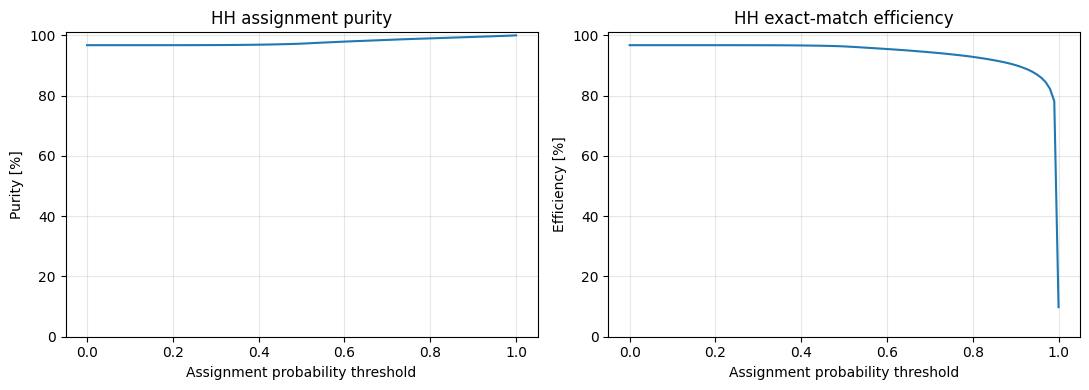

In [4]:
score = target['assignment_probability']
thresholds = np.linspace(0, 1, 101)
rows = []
for threshold in thresholds:
    selected = mask & (score >= threshold)
    selected_correct = selected & correct
    rows.append({
        'threshold': threshold,
        'selected_events': int(selected.sum()),
        'purity [%]': 100 * selected_correct.sum() / selected.sum() if selected.any() else np.nan,
        'efficiency [%]': 100 * selected_correct.sum() / mask.sum(),
    })
threshold_table = pd.DataFrame(rows)
display(threshold_table[threshold_table.threshold.isin([0.1, 0.5, 0.8, 0.9, 0.95, 0.99])])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(threshold_table.threshold, threshold_table['purity [%]'])
axes[0].set(xlabel='Assignment probability threshold', ylabel='Purity [%]', title='HH assignment purity')
axes[1].plot(threshold_table.threshold, threshold_table['efficiency [%]'])
axes[1].set(xlabel='Assignment probability threshold', ylabel='Efficiency [%]', title='HH exact-match efficiency')
for ax in axes: ax.grid(alpha=0.3); ax.set_ylim(0, 101)
fig.tight_layout()
plt.show()


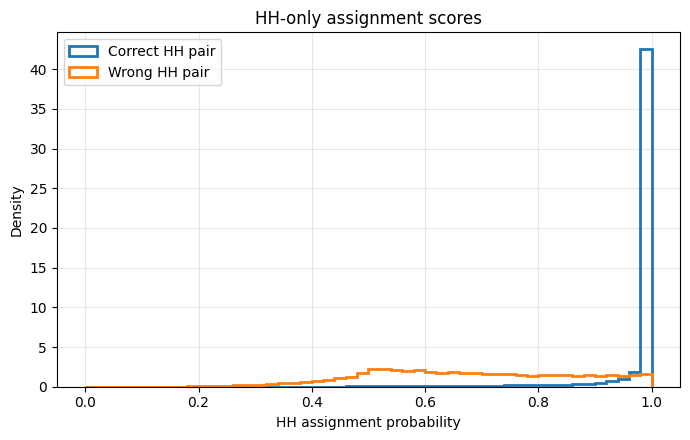

Assignment-score AUC: 0.964239352646954


In [5]:
correct_present = mask & correct
wrong_present = mask & ~correct
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(score[correct_present], bins=50, range=(0, 1), density=True, histtype='step', linewidth=2, label='Correct HH pair')
ax.hist(score[wrong_present], bins=50, range=(0, 1), density=True, histtype='step', linewidth=2, label='Wrong HH pair')
ax.set(xlabel='HH assignment probability', ylabel='Density', title='HH-only assignment scores')
ax.grid(alpha=0.3); ax.legend()
fig.tight_layout(); plt.show()
fpr, tpr, _ = roc_curve(correct[mask], score[mask])
print('Assignment-score AUC:', auc(fpr, tpr))


## 4. Reference HHBTag performance

This is calculated from the reduced ColumnFlow VBF HH parquets using the same generator-to-reconstructed-jet matching used in the failure-diagnostics notebook. It is a reference sample, not the same HDF5 test-event denominator as the SPANet prediction file.

In [6]:
import sys
SPANET_REPO = Path('/home/norman/SPANet')
if not SPANET_REPO.exists(): SPANET_REPO = Path('/local/norman/UHHAnalysis/SPANet')
sys.path.append(str(SPANET_REPO))
from utils.convert_hh_bbtautau_parquet import higgs_bb_truth, matched_truth_indices

UINT64_MISSING = np.iinfo(np.uint64).max
columns = ['Jet.eta', 'Jet.phi', 'Jet.deterministic_seed', 'HHBJet.deterministic_seed', 'GenPart.pt', 'GenPart.eta', 'GenPart.phi', 'GenPart.mass', 'GenPart.pdgId', 'GenPart.status', 'GenPart.genPartIdxMother']
tagger_correct = []
truth_ready = 0
for file in sorted(REDUCED_DIR.glob('events_*.parquet')):
    events = ak.from_parquet(file, columns=columns)
    b1, b2 = matched_truth_indices(higgs_bb_truth(events), events.Jet, 0.4)
    idx = np.column_stack([b1, b2])
    valid = np.all(idx >= 0, axis=1)
    safe = idx.copy(); safe[safe < 0] = 0
    jet_seeds = ak.to_numpy(ak.fill_none(ak.pad_none(events.Jet.deterministic_seed, 16, axis=1, clip=True), np.uint64(UINT64_MISSING)))
    truth_seeds = jet_seeds[np.arange(len(jet_seeds))[:, None], safe]
    truth_seeds[~valid] = UINT64_MISSING
    tagger = ak.to_numpy(ak.fill_none(ak.pad_none(events.HHBJet.deterministic_seed, 2, axis=1, clip=True), np.uint64(UINT64_MISSING)))
    tagger_valid = np.all(tagger != UINT64_MISSING, axis=1)
    exact = valid & tagger_valid & np.all(np.sort(tagger, axis=1) == np.sort(truth_seeds, axis=1), axis=1)
    tagger_correct.extend(exact[valid].tolist())
    truth_ready += int(valid.sum())

hhbtag_reference = pd.DataFrame([{
    'method': 'HHBTag',
    'truth-ready events': truth_ready,
    'exact HH pair match [%]': 100 * np.mean(tagger_correct),
}])
display(hhbtag_reference)
display(pd.DataFrame([{
    'method': 'HH-only SPANet',
    'truth-ready events': int(mask.sum()),
    'exact HH pair match [%]': 100 * correct.sum() / mask.sum(),
}, {
    'method': 'HHBTag reference',
    'truth-ready events': truth_ready,
    'exact HH pair match [%]': 100 * np.mean(tagger_correct),
}]))


,method,truth-ready events,exact HH pair match [%]
0,HHBTag,98242,96.589035


,method,truth-ready events,exact HH pair match [%]
0,HH-only SPANet,494181,96.737026
1,HHBTag reference,98242,96.589035


## 5. Interpretation

Compare the HH-only exact-match rate with the joint model and the HHBTag reference. The HH-only model is a controlled test of multitask interference; its result should not be interpreted as a final ColumnFlow comparison until both methods are evaluated on the same event collection.